In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Newton's Method Optimization
### Single Variable
- Implement the <b>Gradient decent and Newton's method</b> as a function and find the minimum of the following function:
    - $𝒇(𝒙)=𝒙^𝟐−𝟏𝟓𝒙+𝟏$,        
- Draw the functions and check out the minimum.
- Draw the 1st derivative of the function and check out the root.
- Draw 2nd derivative of the function and check out the sign at the minimum.
- The stop condition is grad < epsilon.
- Try different epsilons and initial conditions.
- Compare the results with Gradient descent.
##### The function should return the solution and the gradient.

##### Notes:
- You will need to pass the expression of the function, first, and second derivatives to the optimizer.
- You can use lambda expression to construct the function, first, and second derivatives.

In [14]:
f = lambda x: x**2 - 15*x +1
Df = lambda x: 2*x -15
DDf = lambda x: 2

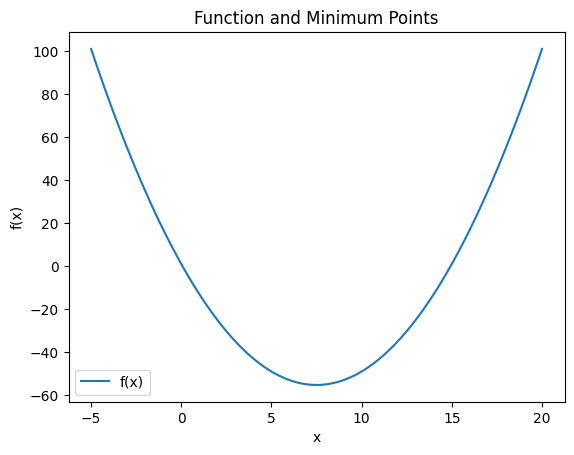

In [3]:
x_vals = np.linspace(-5, 20, 100)
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Function and Minimum Points')
plt.show()



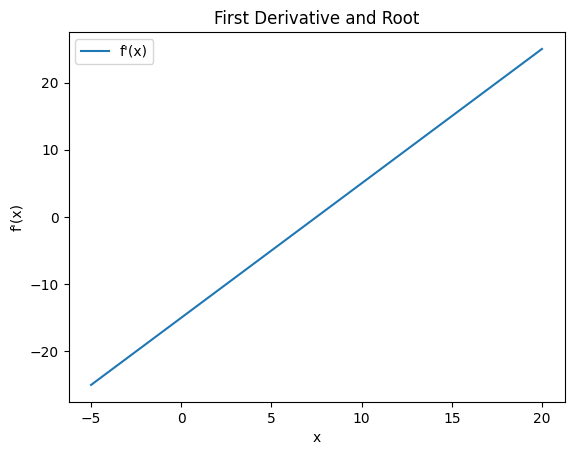

In [4]:
y_prime_vals = Df(x_vals)
plt.plot(x_vals, y_prime_vals, label="f'(x)")
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()
plt.title('First Derivative and Root')
plt.show()




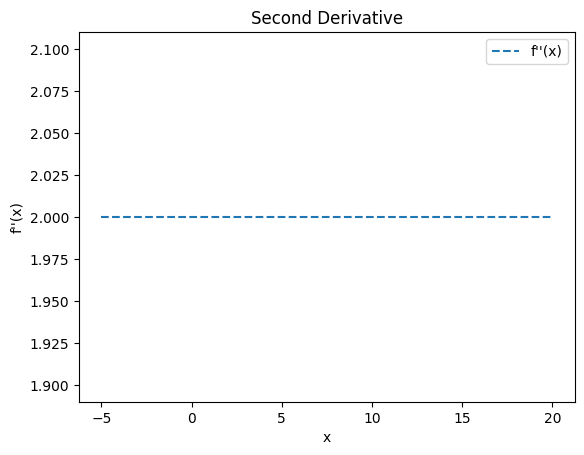

In [15]:

y_double_prime_vals = DDf(x_vals)
y_double_prime_vals = np.full_like(x_vals, DDf(0)) 
plt.plot(x_vals, y_double_prime_vals, label="f''(x)", linestyle='--')
plt.xlabel('x')
plt.ylabel("f''(x)")
plt.title('Second Derivative')
plt.legend()
plt.show()

In [16]:
def newton_method(x0, epsilon=1e-5, max_iter=100):
    x = x0
    history = [x]
    for _ in range(max_iter):
        grad = Df(x)
        if abs(grad) < epsilon:
            break
        x = x - grad / DDf(x)
        history.append(x)
    return x, history,grad

In [17]:
def gradient_descent(x0, alpha=0.1, epsilon=1e-5, max_iter=10000):
    x = x0
    history = [x]
    for i in range(max_iter):
        grad = Df(x)
        if abs(grad) < epsilon:
            break
        x = x - alpha * grad
        history.append(x)
        
        if i > 0 and abs(history[-1] - history[-2]) < 0.001:
            break
    return x, history,grad

In [18]:
x, history,grad=gradient_descent(x0=40, alpha=0.1, epsilon=0.1, max_iter=10)
print("x_min = ",x)
print("Gradient  = ",grad)

x_min =  10.989660928000001
Gradient  =  8.724152320000002


In [19]:
x, history,grad=gradient_descent(x0=40, alpha=0.1, epsilon=0.1, max_iter=100)
print("x_min = ",x)
print("Gradient  = ",grad)

x_min =  7.540233051276774
Gradient  =  0.08046610255354736


In [20]:
x, history,grad=gradient_descent(x0=40, alpha=0.1, epsilon=0.1, max_iter=1000)
print("x_min = ",x)
print("Gradient  = ",grad)

x_min =  7.540233051276774
Gradient  =  0.08046610255354736


In [21]:
# Gradient descent with learning rate = 0.01, x0=40, epsilon = 0.1
x, history,grad=gradient_descent(x0=40, alpha=0.01, epsilon=0.1, max_iter=1000)
print("x_min = ",x)
print("Gradient  = ",grad)

x_min =  7.549596800192111
Gradient  =  0.09919360038422198


In [22]:
x, history,grad=newton_method(x0=40, epsilon=0.1, max_iter=1000)
print("x_min = ",x)
print("Gradient  = ",grad)

x_min =  7.5
Gradient  =  0.0


In [23]:
# Newton's method without learning rate, x0=40, epsilon = 0.1
x, history,grad=newton_method(x0=40, epsilon=0.1, max_iter=1000)
print("x_min = ",x)
print("Gradient  = ",grad)

x_min =  7.5
Gradient  =  0.0


In [24]:
def newton_method_with_alpha(x0, epsilon=0.1, max_iter=100, alpha=0.8):
    x = x0
    alpha = 0.8  # Updated learning rate
    history = [x]
    for _ in range(max_iter):
        grad = Df(x)
        if abs(grad) < epsilon:
            break
        x = x - alpha * (grad / DDf(x))
        history.append(x)
    return x, history,grad

In [25]:
# Newton's method with learning rate = 0.8, x0=40, epsilon = 0.1
x, history,grad=newton_method_with_alpha(x0=40, epsilon=0.1, max_iter=100, alpha=0.8)
print("x_min = ",x)
print("Gradient  = ",grad)


x_min =  7.5104
Gradient  =  0.020799999999999486


### Multi Variable
- Implement the <b>Gradient decent and Newton's method</b> as a function and find the minimum of the following function:
    - $𝒇(𝒙)=𝒙^𝟐+y^2$
    - $𝒇(𝒙)=𝒙^𝟐+xy+y^2$  
    - $𝒇(𝒙)=𝒙^𝟐y$ 
- The stop condition is grad < epsilon.
- Try different epsilons and initial conditions.
- Compare the results with Gradient descent.
##### The function shgould return the solution and the gradient.

In [26]:
from sympy import *
from sympy.plotting import plot3d

$𝒇(𝒙)=𝒙^𝟐+y^2$

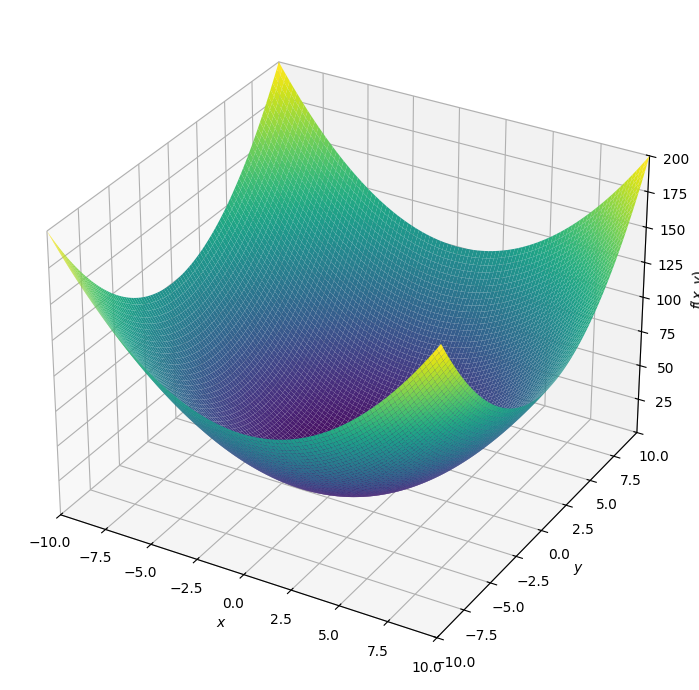

In [27]:
x,y = symbols('x y')
f = x**2 + y**2
plot3d(f,size=(10,7))
plt.show()

$𝒇(𝒙)=𝒙^𝟐+xy+y^2$  

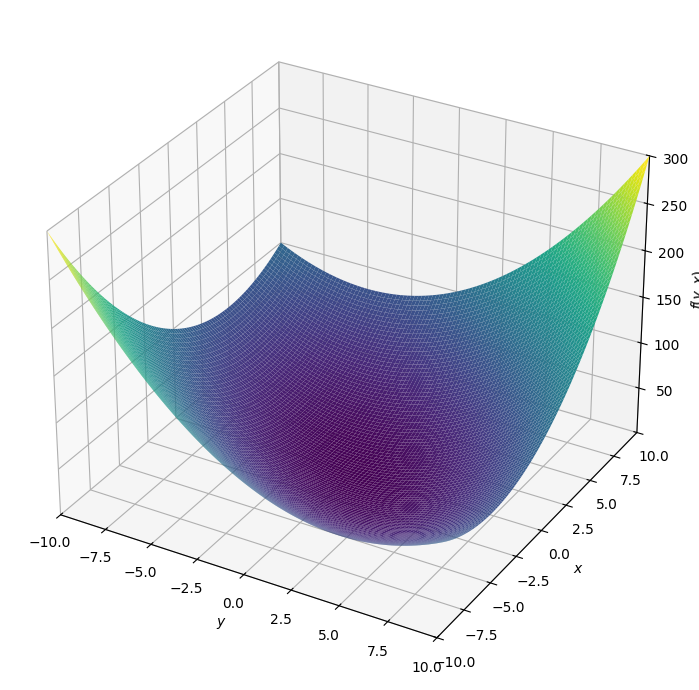

In [38]:
x,y = symbols('x y')
f = x**2 + x * y + y**2
plot3d(f,size=(10,7))
plt.show()

$𝒇(𝒙)=𝒙^𝟐y$ 

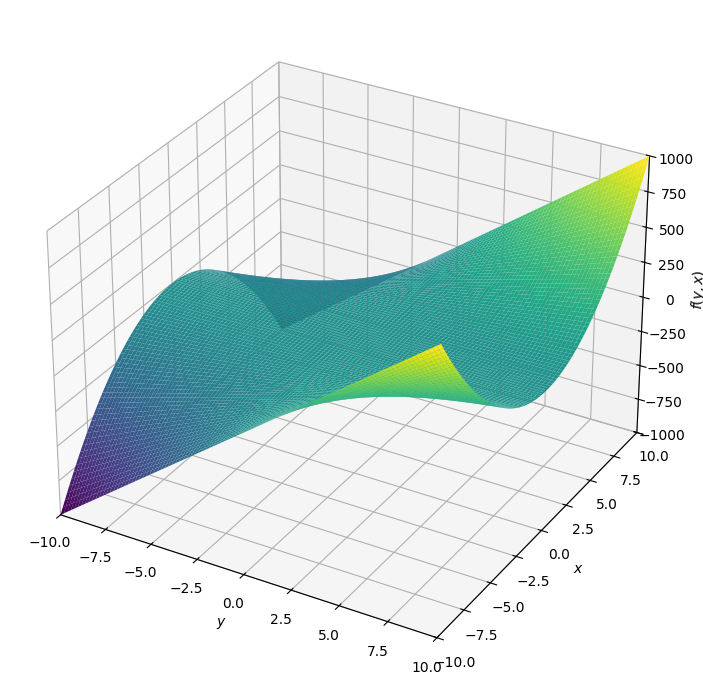

In [39]:
x,y = symbols('x y')
f = x**2 * y
plot3d(f,size=(10,7))
plt.show()

In [28]:
def newton_method(grad_f, hessian_f, x0, epsilon=0.1, max_iter=100, alpha=0.8):
    x = np.array(x0, dtype=float)
    history = [x]
    for i in range(max_iter):
        grad = grad_f(x)
        if np.linalg.norm(grad) < epsilon:
            print(f"Found solution after {i} iterations.")
            print(f"xy_min = {x}")
            print(f"Gradient = {grad}")
            return x, history
        hessian_inv = np.linalg.inv(hessian_f(x))
        x = x - alpha * hessian_inv @ grad
        history.append(x)
    return x, history,grad

def gradient_descent( grad_f, x0, alpha=0.1, epsilon=0.001, max_iter=10000):
    x = np.array(x0, dtype=float)
    history = [x]
    for i in range(max_iter):
        grad = grad_f(x)
        if np.linalg.norm(grad) < epsilon:
            print(f"Found solution after {i} iterations.")
            print(f"xy_min = {x}")
            print(f"Gradient = {grad}")
            return x, history
        x = x - alpha * grad
        history.append(x)
    return x, history,grad


In [29]:
f_1 = lambda x: x**2  + y**2
Df_1 = lambda X: np.array([2*X[0],2*X[1]])
DDf_1 = lambda X: np.array([[2,0],
                         [0,2]])

In [30]:
# First function
# Multi-variable Gradient descent with learning rate = 0.1,
# x0=(10,10), epsilon = 0.001
_=gradient_descent( Df_1, 
                    x0=[10, 10], 
                    alpha=0.1, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 46 iterations.
xy_min = [0.00034845 0.00034845]
Gradient = [0.0006969 0.0006969]


In [31]:
_=gradient_descent( Df_1, 
                    x0=[10, 10], 
                    alpha=0.01, 
                    epsilon=0.001, 
                    max_iter=1000)

Found solution after 508 iterations.
xy_min = [0.00034902 0.00034902]
Gradient = [0.00069803 0.00069803]


In [32]:
# First function
# Multi-variable Gradient descent with learning rate = 0.5,
# x0=(10,10), epsilon = 0.001
_=gradient_descent( Df_1, 
                    x0=[10, 10], 
                    alpha=0.5, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 1 iterations.
xy_min = [0. 0.]
Gradient = [0. 0.]


In [33]:
# First function
# Multi-variable Newton's method without learning rate, 
# x0=(10,10), epsilon = 0.001
_=newton_method( Df_1, DDf_1,
                    x0=[10, 10], 
                    alpha=1, # alpha=1 this mean without learning rate, 
                    epsilon=0.001, 
                    max_iter=1000)

Found solution after 1 iterations.
xy_min = [0. 0.]
Gradient = [0. 0.]


In [34]:
# First function
# Multi-variable Newton's method with learning rate = 0.5, 
# x0=(10,10), epsilon = 0.001
_=newton_method( Df_1, DDf_1,
                    x0=[10, 10], 
                    alpha=.5, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 15 iterations.
xy_min = [0.00030518 0.00030518]
Gradient = [0.00061035 0.00061035]


In [35]:
f_2 = lambda x: x**2 + x*y + y**2
Df_2 = lambda X: np.array([2*X[0]+X[1],2*X[1]+X[0]])
DDf_2 = lambda X: np.array([[2,1],
                        [1,2]])

In [36]:
# Second function
# Multi-variable Gradient descent with learning rate = 0.5,
# x0=(10,10), epsilon = 0.001
_=gradient_descent( Df_2, 
                    x0=[10, 10], 
                    alpha=.5, 
                    epsilon=0.001, 
                    max_iter=1000)

Found solution after 16 iterations.
xy_min = [0.00015259 0.00015259]
Gradient = [0.00045776 0.00045776]


In [37]:
# Second function
# Multi-variable Newton's method without learning rate, 
# x0=(10,10), epsilon = 0.001
_=newton_method( Df_2, DDf_2,
                    x0=[10, 10], 
                    alpha=1, # alpha=1 this mean without learning rate, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 1 iterations.
xy_min = [0. 0.]
Gradient = [0. 0.]


In [38]:
# Second function
# Multi-variable Newton's method with learning rate = 0.9, 
# x0=(10,10), epsilon = 0.001
_=newton_method( Df_2, DDf_2,
                    x0=[10, 10], 
                    alpha=0.9, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 5 iterations.
xy_min = [0.0001 0.0001]
Gradient = [0.0003 0.0003]


In [39]:
f_5 = lambda x: x**2 * y
Df_5 = lambda X: np.array([2*X[0]*X[1],
                           X[0]**2])
DDf_5 = lambda X: np.array([[2*X[1],2*X[0]],
                         [2*X[0],0]])

In [40]:
# Third function
# Multi-variable Gradient descent with learning rate = 0.01,
# x0=(10,10), epsilon = 0.001
_=gradient_descent( Df_5, 
                    x0=[10, 10], 
                    alpha=.01, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 79 iterations.
xy_min = [6.80598421e-05 6.85061189e+00]
Gradient = [9.32503127e-04 4.63214210e-09]


In [41]:
# Third function
# Multi-variable Newton's method without learning rate, 
# x0=(10,10), epsilon = 0.001
_=newton_method( Df_5, DDf_5,
                    x0=[10, 10], 
                    alpha=1, 
                    epsilon=0.001, 
                    max_iter=1000)


Found solution after 9 iterations.
xy_min = [0.01953125 0.01953125]
Gradient = [0.00076294 0.00038147]


## BFGS
- Implement the <b>BFGS</b> as a function and find the minimum of the following function:
    - $𝒇(𝒙)=𝒙^𝟐+y^2$
    - $𝒇(𝒙)=𝒙^𝟐+xy+y^2$  
    - $𝒇(𝒙)=𝒙^𝟐y$ 
- The stop condition is grad < epsilon.
- Try different epsilons and initial conditions.
- Compare the results from Gradient descent and Newton's method.

In [54]:
f1 = lambda x: x[0]**2 + x[1]**2
f2 = lambda x: x[0]**2 + x[0]*x[1] + x[1]**2
f3 = lambda x: x[0]**2 * x[1]

In [43]:

def bfgs_method(Df,Xk_1, x0, epsilon,alpha=1):
    Xk = np.array(x0, dtype=float)
    Xk_1 = np.array(Xk_1, dtype=float) 
    I_matrix = np.eye(len(Xk))  
    Bt_1_inv = np.eye(len(Xk)) 
    iters=0
    for i in range(10000):
        if np.linalg.norm(Df(Xk))<epsilon:
            break
        d_x=Xk-Xk_1 
        y=Df(Xk)-Df(Xk_1)  
        B_inv = (I_matrix - (np.outer(d_x, y) / (y @ d_x))) @ Bt_1_inv @ (I_matrix - (np.outer(y, d_x) / (y @ d_x))) + (np.outer(d_x, d_x) / (y @ d_x))
        Xk_1 = Xk
        Xk = Xk + alpha * (-B_inv @ Df(Xk))
        iters=i+1
    print(f"Found solution after {iters} iterations")
    print(f"xn_1: {Xk_1} ")
    print(f"xn : {Xk}")
    print(f"xy_min = {Xk}")
    print(f"Gradient = {Df(Xk)}")

In [56]:
## First function
## BFGD with xk-1 = (10,10) and x0 = (9,9), epsilon = 0.001
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001
bfgs_method(Df_1, xk_1,x0=x0, epsilon=0.001, alpha=1)

Found solution after 1 iterations
xn_1: [9. 9.] 
xn : [0. 0.]
xy_min = [0. 0.]
Gradient = [0. 0.]


In [48]:
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001

bfgs_method(Df_1, xk_1,x0=x0, epsilon=0.001, alpha=.1)

Found solution after 97 iterations
xn_1: [0.00036435 0.00036435] 
xn : [0.00032792 0.00032792]
xy_min = [0.00032792 0.00032792]
Gradient = [0.00065584 0.00065584]


In [57]:
## First function
## BFGD with xk-1 = (10,10) and x0 = (9,9), epsilon = 0.001, 
## learning rate =0.9
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001
bfgs_method(Df_1, xk_1,x0=x0, epsilon=0.001, alpha=.9)

Found solution after 5 iterations
xn_1: [0.0009 0.0009] 
xn : [9.e-05 9.e-05]
xy_min = [9.e-05 9.e-05]
Gradient = [0.00018 0.00018]


In [58]:
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001
bfgs_method(Df_1, xk_1,x0=x0, epsilon=0.001, alpha=.9)

Found solution after 5 iterations
xn_1: [0.0009 0.0009] 
xn : [9.e-05 9.e-05]
xy_min = [9.e-05 9.e-05]
Gradient = [0.00018 0.00018]


In [59]:
## Second function
## BFGD with xk-1 = (10,10) and x0 = (9,9), epsilon = 0.001
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001

bfgs_method(Df_2, xk_1,x0=x0, epsilon=0.001, alpha=1)

Found solution after 1 iterations
xn_1: [9. 9.] 
xn : [1.77635684e-15 1.77635684e-15]
xy_min = [1.77635684e-15 1.77635684e-15]
Gradient = [5.32907052e-15 5.32907052e-15]


In [60]:
## Second function
## BFGD with xk-1 = (10,10) and x0 = (9,9), epsilon = 0.001,
## learning rate  = 0.9
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001

bfgs_method(Df_2, xk_1,x0=x0, epsilon=0.001, alpha=.9)

Found solution after 5 iterations
xn_1: [0.0009 0.0009] 
xn : [9.e-05 9.e-05]
xy_min = [9.e-05 9.e-05]
Gradient = [0.00027 0.00027]


In [61]:
## Third function
## BFGD with xk-1 = (10,10) and x0 = (9,9), epsilon = 0.001
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001

bfgs_method(Df_5, xk_1,x0=x0, epsilon=0.001, alpha=1)

Found solution after 13 iterations
xn_1: [0.02482074 0.02482074] 
xn : [0.01534004 0.01534004]
xy_min = [0.01534004 0.01534004]
Gradient = [0.00047063 0.00023532]


In [62]:
x0 = np.array([9, 9], dtype=float)
xk_1 = np.array([10, 10], dtype=float)
epsilon = 0.001

bfgs_method(Df_5, xk_1,x0=x0, epsilon=0.001, alpha=.9)

Found solution after 14 iterations
xn_1: [0.0283729 0.0283729] 
xn : [0.01834551 0.01834551]
xy_min = [0.01834551 0.01834551]
Gradient = [0.00067312 0.00033656]
